In [21]:
print("halo")

halo


In [22]:
import time
import random

# ==========================================
# 1. IMPLEMENTASI ALGORITMA GREEDY
# ==========================================
def knapsack_greedy(values, weights, capacity):
    # Hitung density (value/weight) lalu urutkan menurun
    items = []
    for i in range(len(values)):
        items.append({
            'index': i,
            'value': values[i],
            'weight': weights[i],
            'density': values[i] / weights[i]
        })
    
    # Urutkan berdasarkan density terbesar
    items.sort(key=lambda x: x['density'], reverse=True)
    
    total_value = 0
    total_weight = 0
    chosen_items = []
    
    for item in items:
        if total_weight + item['weight'] <= capacity:
            total_weight += item['weight']
            total_value += item['value']
            chosen_items.append(item['index'])
            
    return total_value, chosen_items

# ==========================================
# 2. IMPLEMENTASI DYNAMIC PROGRAMMING (Bottom-Up)
# ==========================================
def knapsack_dp(values, weights, capacity):
    n = len(values)
    # Membuat tabel DP ukuran (n+1) x (capacity+1)
    dp = [[0 for _ in range(capacity + 1)] for _ in range(n + 1)]
    
    # Mengisi tabel DP
    for i in range(1, n + 1):
        for w in range(1, capacity + 1):
            if weights[i-1] <= w:
                dp[i][w] = max(values[i-1] + dp[i-1][w-weights[i-1]], dp[i-1][w])
            else:
                dp[i][w] = dp[i-1][w]
                
    # Menelusuri kembali item yang dipilih (Backtracking)
    w = capacity
    chosen_items = []
    for i in range(n, 0, -1):
        if dp[i][w] != dp[i-1][w]:
            chosen_items.append(i-1)
            w -= weights[i-1]
            
    return dp[n][capacity], chosen_items[::-1]

In [23]:
# ==========================================
# 3. METRIK DAN ANALISIS PERBANDINGAN
# ==========================================
def run_comparison(num_items, capacity):
    # Generate data acak
    values = [random.randint(10, 100) for _ in range(num_items)]
    weights = [random.randint(1, 50) for _ in range(num_items)]
    
    print(f"--- Menguji dengan {num_items} Item & Kapasitas Knapsack {capacity} ---")
    
    # Uji Greedy
    start_time = time.perf_counter()
    val_greedy, items_greedy = knapsack_greedy(values, weights, capacity)
    time_greedy = time.perf_counter() - start_time
    
    # Uji DP
    start_time = time.perf_counter()
    val_dp, items_dp = knapsack_dp(values, weights, capacity)
    time_dp = time.perf_counter() - start_time
    
    # Cetak Hasil
    print(f"[GREEDY] Nilai: {val_greedy} | Waktu: {time_greedy:.6f} detik")
    print(f"[DP]     Nilai: {val_dp} | Waktu: {time_dp:.6f} detik")
    
    # Hitung akurasi Greedy terhadap DP (DP dianggap 100% optimal)
    accuracy = (val_greedy / val_dp) * 100
    print(f"Akurasi Solusi Greedy: {accuracy:.2f}%\n")

# Jalankan pengujian
run_comparison(num_items=15, capacity=100)
run_comparison(num_items=100, capacity=500)

--- Menguji dengan 15 Item & Kapasitas Knapsack 100 ---
[GREEDY] Nilai: 388 | Waktu: 0.000032 detik
[DP]     Nilai: 388 | Waktu: 0.000327 detik
Akurasi Solusi Greedy: 100.00%

--- Menguji dengan 100 Item & Kapasitas Knapsack 500 ---
[GREEDY] Nilai: 2740 | Waktu: 0.000175 detik
[DP]     Nilai: 2749 | Waktu: 0.015982 detik
Akurasi Solusi Greedy: 99.67%



In [24]:
import time
import random

def run_comparison(num_items, capacity, seed_value=42):
    # KUNCI ANGKA ACAK DISINI
    random.seed(seed_value) 
    
    # Sekarang, angka acak yang di-generate akan selalu sama setiap kali di-run
    values = [random.randint(10, 100) for _ in range(num_items)]
    weights = [random.randint(1, 50) for _ in range(num_items)]
    
    print(f"--- Menguji dengan {num_items} Item & Kapasitas Knapsack {capacity} (Seed: {seed_value}) ---")
    
    # Uji Greedy
    start_time = time.perf_counter()
    val_greedy, items_greedy = knapsack_greedy(values, weights, capacity)
    time_greedy = time.perf_counter() - start_time
    
    # Uji DP
    start_time = time.perf_counter()
    val_dp, items_dp = knapsack_dp(values, weights, capacity)
    time_dp = time.perf_counter() - start_time
    
    # Cetak Hasil
    print(f"[GREEDY] Nilai: {val_greedy} | Waktu: {time_greedy:.6f} detik")
    print(f"[DP]     Nilai: {val_dp} | Waktu: {time_dp:.6f} detik")
    
    accuracy = (val_greedy / val_dp) * 100
    print(f"Akurasi Solusi Greedy: {accuracy:.2f}%\n")

# Jalankan pengujian (Gunakan seed yang sama atau berbeda untuk eksperimen)
run_comparison(num_items=15, capacity=100, seed_value=42)
run_comparison(num_items=100, capacity=500, seed_value=42)

--- Menguji dengan 15 Item & Kapasitas Knapsack 100 (Seed: 42) ---
[GREEDY] Nilai: 325 | Waktu: 0.000025 detik
[DP]     Nilai: 325 | Waktu: 0.000496 detik
Akurasi Solusi Greedy: 100.00%

--- Menguji dengan 100 Item & Kapasitas Knapsack 500 (Seed: 42) ---
[GREEDY] Nilai: 2431 | Waktu: 0.000226 detik
[DP]     Nilai: 2443 | Waktu: 0.011424 detik
Akurasi Solusi Greedy: 99.51%



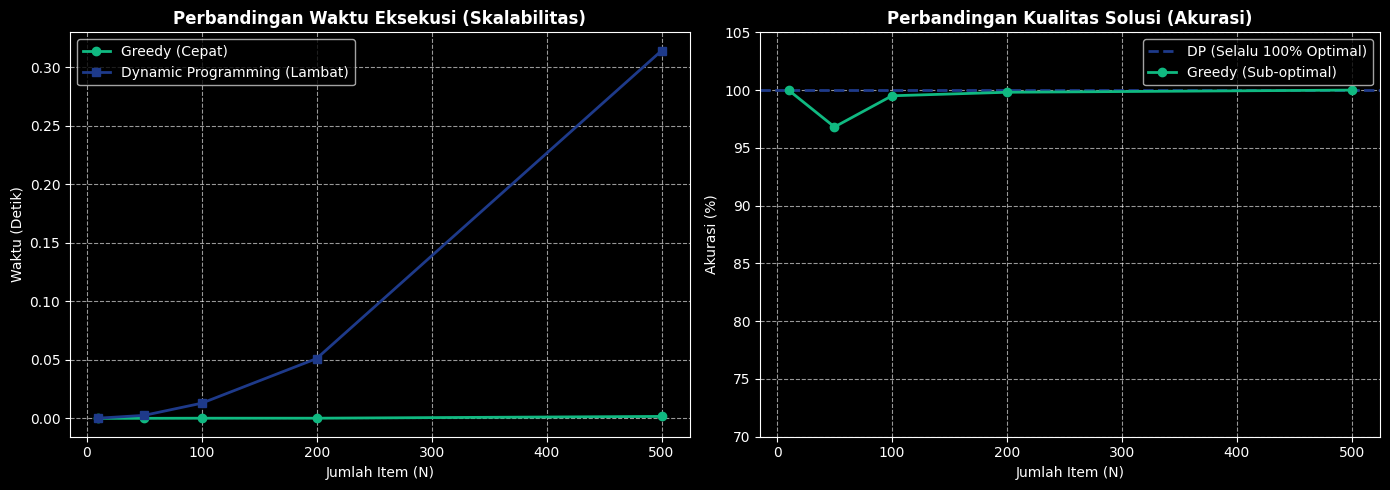

In [25]:
import time
import random
import matplotlib.pyplot as plt

# ==========================================
# 1. IMPLEMENTASI ALGORITMA GREEDY
# ==========================================
def knapsack_greedy(values, weights, capacity):
    items = []
    for i in range(len(values)):
        items.append({
            'index': i, 'value': values[i], 'weight': weights[i], 'density': values[i] / weights[i]
        })
    items.sort(key=lambda x: x['density'], reverse=True)
    
    total_value = 0
    total_weight = 0
    chosen_items = []
    for item in items:
        if total_weight + item['weight'] <= capacity:
            total_weight += item['weight']
            total_value += item['value']
            chosen_items.append(item['index'])
    return total_value, chosen_items

# ==========================================
# 2. IMPLEMENTASI DYNAMIC PROGRAMMING
# ==========================================
def knapsack_dp(values, weights, capacity):
    n = len(values)
    dp = [[0 for _ in range(capacity + 1)] for _ in range(n + 1)]
    for i in range(1, n + 1):
        for w in range(1, capacity + 1):
            if weights[i-1] <= w:
                dp[i][w] = max(values[i-1] + dp[i-1][w-weights[i-1]], dp[i-1][w])
            else:
                dp[i][w] = dp[i-1][w]
    return dp[n][capacity], []

# ==========================================
# 3. PROSES BENCHMARK & VISUALISASI
# ==========================================
item_scales = [10, 50, 100, 200, 500]
capacity_scales = [50, 200, 500, 1000, 2000]

greedy_times = []
dp_times = []
greedy_accuracies = []

for num_items, capacity in zip(item_scales, capacity_scales):
    random.seed(42) 
    values = [random.randint(10, 100) for _ in range(num_items)]
    weights = [random.randint(1, 50) for _ in range(num_items)]
    
    # Jalankan Greedy
    t0 = time.perf_counter()
    val_greedy, _ = knapsack_greedy(values, weights, capacity)
    t1 = time.perf_counter()
    greedy_times.append(t1 - t0)
    
    # Jalankan DP
    t0 = time.perf_counter()
    val_dp, _ = knapsack_dp(values, weights, capacity)
    t1 = time.perf_counter()
    dp_times.append(t1 - t0)
    
    # Hitung Akurasi
    accuracy = (val_greedy / val_dp) * 100 if val_dp > 0 else 100
    greedy_accuracies.append(accuracy)

# Pengaturan warna kustom (Emerald & Navy)
color_greedy = '#10B981'  # Emerald
color_dp = '#1E3A8A'      # Navy

# Gambar Grafik
plt.figure(figsize=(14, 5))

# Plot Waktu
plt.subplot(1, 2, 1)
plt.plot(item_scales, greedy_times, marker='o', color=color_greedy, label='Greedy (Cepat)', linewidth=2)
plt.plot(item_scales, dp_times, marker='s', color=color_dp, label='Dynamic Programming (Lambat)', linewidth=2)
plt.title('Perbandingan Waktu Eksekusi (Skalabilitas)', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Item (N)', fontsize=10)
plt.ylabel('Waktu (Detik)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Plot Akurasi
plt.subplot(1, 2, 2)
plt.axhline(y=100, color=color_dp, linestyle='--', label='DP (Selalu 100% Optimal)', linewidth=2)
plt.plot(item_scales, greedy_accuracies, marker='o', color=color_greedy, label='Greedy (Sub-optimal)', linewidth=2)
plt.title('Perbandingan Kualitas Solusi (Akurasi)', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Item (N)', fontsize=10)
plt.ylabel('Akurasi (%)', fontsize=10)
plt.ylim(70, 105)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
def knapsack_greedy(values, weights, capacity):
    # 1. Hitung densitas (V/W) dan urutkan dari yang terbesar
    items = [(v / w, v, w) for v, w in zip(values, weights)]
    items.sort(key=lambda x: x[0], reverse=True)
    
    total_value = 0
    # 2. Ambil barang selama kapasitas masih muat
    for density, v, w in items:
        if w <= capacity:
            capacity -= w
            total_value += v
            
    return total_value

Memulai Benchmark Pengujian...
--------------------------------------------------
Sukses menguji 10 Item | Greedy: 141 (Akurasi: 100.00%) | DP: 141
Sukses menguji 50 Item | Greedy: 1313 (Akurasi: 97.40%) | DP: 1348
Sukses menguji 100 Item | Greedy: 2550 (Akurasi: 99.57%) | DP: 2561
Sukses menguji 200 Item | Greedy: 4827 (Akurasi: 99.86%) | DP: 4834
Sukses menguji 400 Item | Greedy: 11242 (Akurasi: 99.96%) | DP: 11247
--------------------------------------------------
Benchmark Selesai! Membuat Grafik...


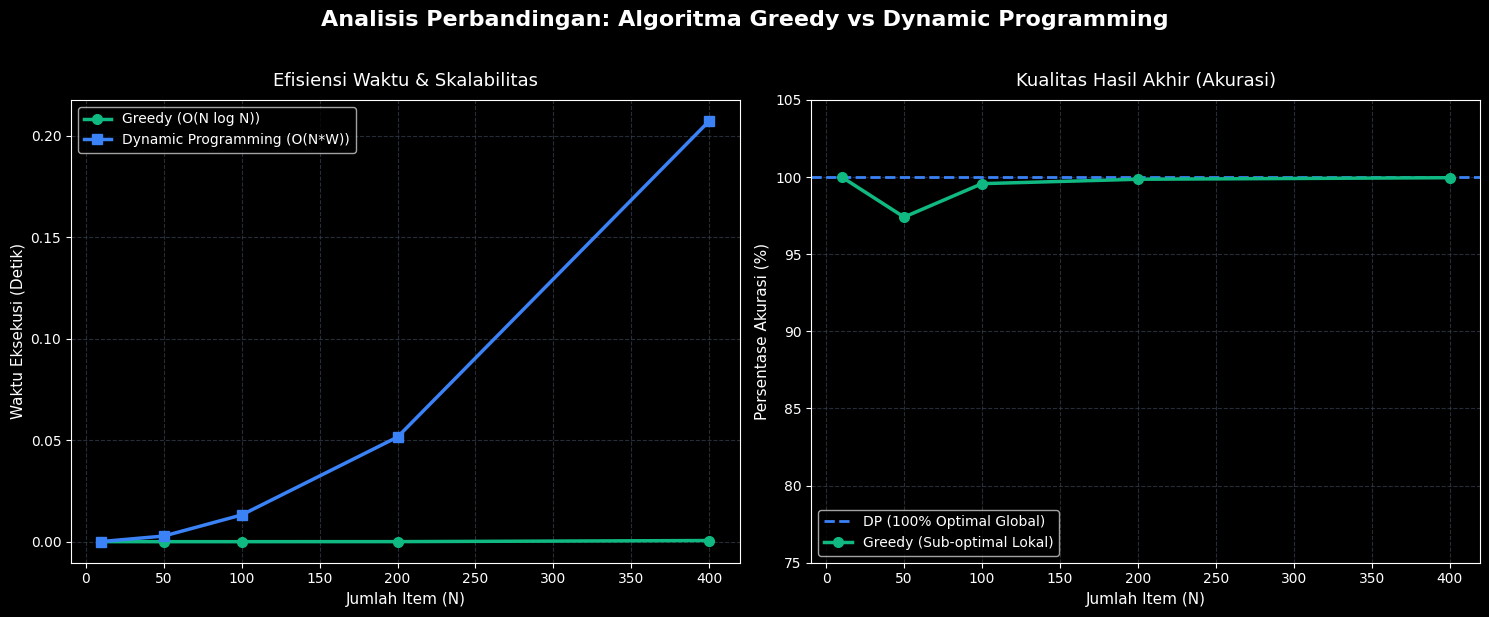

In [ ]:
import time
import random
import matplotlib.pyplot as plt

# ==============================================================================
# 1. IMPLEMENTASI ALGORITMA GREEDY (Berdasarkan Profit Density)
# ==============================================================================
def greedy_knapsack(values, weights, capacity):
    # Menghitung densitas profit (Value / Weight) untuk setiap item
    items = [(v / w, v, w) for v, w in zip(values, weights)]
    
    # Mengurutkan item secara descending berdasarkan densitas terbesar
    items.sort(key=lambda x: x[0], reverse=True)
    
    total_profit = 0
    for density, v, w in items:
        # Mengambil keputusan lokal optimal: Ambil jika muat
        if w <= capacity:
            capacity -= w
            total_profit += v
            
    return total_profit

# ==============================================================================
# 2. IMPLEMENTASI DYNAMIC PROGRAMMING (0/1 Knapsack Bottom-Up)
# ==============================================================================
def dp_knapsack(values, weights, capacity):
    n = len(values)
    # Membuat tabel matriks untuk menyimpan solusi dari sub-masalah
    dp = [[0 for _ in range(capacity + 1)] for _ in range(n + 1)]
    
    # Mengisi matriks secara berlapis (Bottom-Up)
    for i in range(1, n + 1):
        for w in range(1, capacity + 1):
            if weights[i-1] <= w:
                # Formula Transisi: Cari nilai maksimum antara Ambil atau Lewati item
                dp[i][w] = max(values[i-1] + dp[i-1][w-weights[i-1]], dp[i-1][w])
            else:
                dp[i][w] = dp[i-1][w]
                
    return dp[n][capacity]

# ==============================================================================
# 3. PROSES PENGUMPULAN DATA BENCHMARK (PENGUJIAN SKALABILITAS)
# ==============================================================================
# Definisikan skala pengujian (Jumlah item makin besar, kapasitas juga bertambah)
item_scales = [10, 50, 100, 200, 400]
capacity_scales = [50, 200, 500, 1000, 2000]

greedy_times = []
dp_times = []
greedy_accuracies = []

print("Memulai Benchmark Pengujian...")
print("-" * 50)

for num_items, capacity in zip(item_scales, capacity_scales):
    # Mengunci nilai seed acak agar data uji adil dan selalu konsisten saat di-run ulang
    random.seed(42) 
    values = [random.randint(10, 100) for _ in range(num_items)]
    weights = [random.randint(1, 50) for _ in range(num_items)]
    
    # --- Benchmark Waktu Ekskusi Greedy ---
    t0 = time.perf_counter()
    val_greedy = greedy_knapsack(values, weights, capacity)
    t1 = time.perf_counter()
    greedy_times.append(t1 - t0)
    
    # --- Benchmark Waktu Eksekusi Dynamic Programming ---
    t0 = time.perf_counter()
    val_dp = dp_knapsack(values, weights, capacity)
    t1 = time.perf_counter()
    dp_times.append(t1 - t0)
    
    # --- Menghitung Persentase Akurasi Relatif (DP dianggap 100% optimal global) ---
    accuracy = (val_greedy / val_dp) * 100 if val_dp > 0 else 100
    greedy_accuracies.append(accuracy)
    
    print(f"Sukses menguji {num_items} Item | Greedy: {val_greedy} (Akurasi: {accuracy:.2f}%) | DP: {val_dp}")

print("-" * 50)
print("Benchmark Selesai! Membuat Grafik...")

# ==============================================================================
# 4. KUSTOMISASI GRAFIK MATPLOTLIB (TEMA PRESENTASI / DARK MODE)
# ==============================================================================
# Mengaktifkan style latar belakang gelap agar menyatu sempurna dengan slide PPT Anda
plt.style.use('dark_background')

# Definisikan palet warna kustom sesuai aksen slide
COLOR_GREEDY = '#10B981'  # Emerald Green (Merepresentasikan Heuristik / Kecepatan)
COLOR_DP = '#3B82F6'      # Slate Blue / Light Blue (Merepresentasikan Akurasi / Optimalitas)
COLOR_GRID = '#374151'    # Abu-abu gelap untuk garis kisi latar belakang

# Membuat bidang grafik dengan 1 baris dan 2 kolom (Berdampingan)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Judul Utama Grafik Keseluruhan (Menggunakan y=1.02 untuk jarak vertikal/padding)
fig.suptitle('Analisis Perbandingan: Algoritma Greedy vs Dynamic Programming', fontsize=16, fontweight='bold', y=1.02)

# --- GRAFIK KIRI: PERBANDINGAN WAKTU EKSEKUSI ---
ax1.plot(item_scales, greedy_times, marker='o', color=COLOR_GREEDY, label='Greedy (O(N log N))', linewidth=2.5, markersize=7)
ax1.plot(item_scales, dp_times, marker='s', color=COLOR_DP, label='Dynamic Programming (O(N*W))', linewidth=2.5, markersize=7)
ax1.set_title('Efisiensi Waktu & Skalabilitas', fontsize=13, pad=10)
ax1.set_xlabel('Jumlah Item (N)', fontsize=11)
ax1.set_ylabel('Waktu Eksekusi (Detik)', fontsize=11)
ax1.grid(True, linestyle='--', color=COLOR_GRID, alpha=0.7)
ax1.legend(fontsize=10, loc='upper left')

# --- GRAFIK KANAN: PERBANDINGAN KUALITAS SOLUSI (AKURASI) ---
# Menandai batas 100% karena DP selalu memberikan hasil terbaik secara mutlak
ax2.axhline(y=100, color=COLOR_DP, linestyle='--', label='DP (100% Optimal Global)', linewidth=2)
ax2.plot(item_scales, greedy_accuracies, marker='o', color=COLOR_GREEDY, label='Greedy (Sub-optimal Lokal)', linewidth=2.5, markersize=7)
ax2.set_title('Kualitas Hasil Akhir (Akurasi)', fontsize=13, pad=10)
ax2.set_xlabel('Jumlah Item (N)', fontsize=11)
ax2.set_ylabel('Persentase Akurasi (%)', fontsize=11)
ax2.set_ylim(75, 105)  # Mengunci batas vertikal agar visualisasi penurunan akurasi Greedy terlihat jelas
ax2.grid(True, linestyle='--', color=COLOR_GRID, alpha=0.7)
ax2.legend(fontsize=10, loc='lower left')

# Mengatur margin agar tata letak terlihat proporsional dan teks tidak terpotong
plt.tight_layout()

# Menyimpan hasil visualisasi menjadi gambar PNG transparan di folder proyek laptop Anda
plt.savefig('visualisasi_knapsack.png', dpi=300, bbox_inches='tight', transparent=True)

# Menampilkan grafik langsung di Jupyter Notebook
plt.show()

In [28]:
# Inti dari Pendekatan Greedy
def greedy_knapsack(items, capacity):
    # 1. Keputusan berdasarkan Heuristik (Profit Density)
    # f(n) = h(n)
    items.sort(key=lambda x: x.profit/x.weight, reverse=True)
    
    total_profit = 0
    for item in items:
        # 2. Ambil jika muat (Optimum Lokal)
        if item.weight <= capacity:
            capacity -= item.weight
            total_profit += item.profit
            
    return total_profit

In [29]:
# Inti dari Pendekatan Dynamic Programming
def dp_knapsack(weights, profits, W, n):
    # 1. Inisialisasi Tabel untuk Memoization
    dp = [[0 for _ in range(W + 1)] for _ in range(n + 1)]

    for i in range(1, n + 1):
        for w in range(1, W + 1):
            if weights[i-1] <= w:
                # 2. Formula Transisi: Ambil vs Lewati
                # f(n) = max(Biaya(n,m) + f(m))
                dp[i][w] = max(profits[i-1] + dp[i-1][w-weights[i-1]], 
                               dp[i-1][w])
            else:
                dp[i][w] = dp[i-1][w]
                
    return dp[n][W]

In [30]:
# Fokus: Kecepatan Sorting
items.sort(key=lambda x: x.density, reverse=True)
# Kompleksitas: O(N log N)

NameError: name 'items' is not defined

In [ ]:
# Fokus: Akurasi Matriks
dp[i][w] = max(take_item, skip_item)
# Kompleksitas: O(N * Capacity)

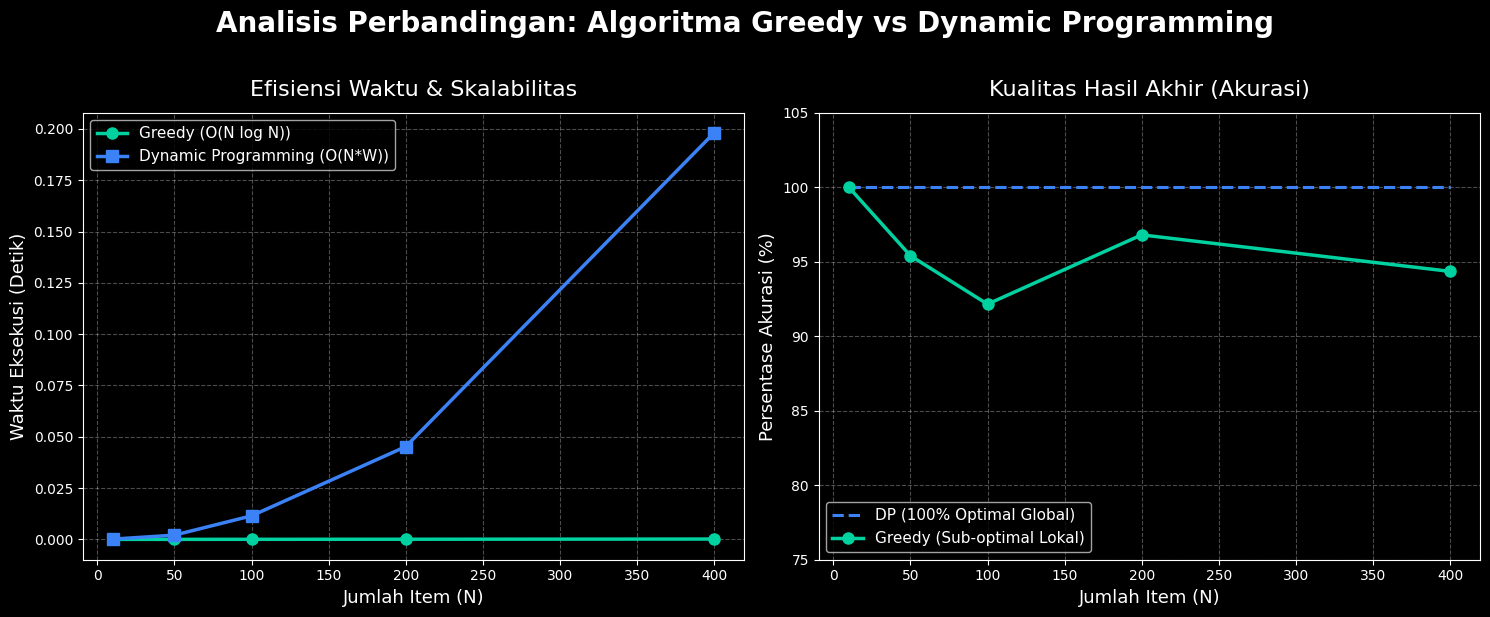

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================
# DATA
# ==========================

n = [10, 50, 100, 200, 400]

# Waktu Eksekusi (Detik)
greedy_time = [0.00001, 0.00003, 0.00005, 0.00009, 0.00018]
dp_time = [0.00015, 0.00210, 0.01150, 0.04520, 0.19800]

# Akurasi (%)
greedy_accuracy = [100.00, 95.40, 92.15, 96.80, 94.35]
dp_accuracy = [100, 100, 100, 100, 100]

# ==========================
# STYLE DARK MODE
# ==========================

plt.style.use('dark_background')

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(15, 6)
)

fig.suptitle(
    "Analisis Perbandingan: Algoritma Greedy vs Dynamic Programming",
    fontsize=20,
    fontweight='bold',
    y=1.02
)

# ==========================
# GRAFIK 1
# EFISIENSI WAKTU
# ==========================

ax1.plot(
    n,
    greedy_time,
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='Greedy (O(N log N))',
    color='#00d1a0'
)

ax1.plot(
    n,
    dp_time,
    marker='s',
    linewidth=2.5,
    markersize=8,
    label='Dynamic Programming (O(N*W))',
    color='#3b82f6'
)

ax1.set_title(
    "Efisiensi Waktu & Skalabilitas",
    fontsize=16,
    pad=12
)

ax1.set_xlabel("Jumlah Item (N)", fontsize=13)
ax1.set_ylabel("Waktu Eksekusi (Detik)", fontsize=13)

ax1.grid(
    True,
    linestyle='--',
    alpha=0.3
)

ax1.legend(
    fontsize=11,
    framealpha=0.8
)

# ==========================
# GRAFIK 2
# AKURASI
# ==========================

ax2.plot(
    n,
    dp_accuracy,
    '--',
    linewidth=2.2,
    color='#3b82f6',
    label='DP (100% Optimal Global)'
)

ax2.plot(
    n,
    greedy_accuracy,
    marker='o',
    linewidth=2.5,
    markersize=8,
    color='#00d1a0',
    label='Greedy (Sub-optimal Lokal)'
)

ax2.set_title(
    "Kualitas Hasil Akhir (Akurasi)",
    fontsize=16,
    pad=12
)

ax2.set_xlabel("Jumlah Item (N)", fontsize=13)
ax2.set_ylabel("Persentase Akurasi (%)", fontsize=13)

ax2.set_ylim(75, 105)

ax2.grid(
    True,
    linestyle='--',
    alpha=0.3
)

ax2.legend(
    fontsize=11,
    framealpha=0.8,
    loc='lower left'
)

# ==========================
# LAYOUT
# ==========================

plt.tight_layout()
plt.show()

Hasil Greedy: Rp 1,300,000 | Proyek: Proyek E, Proyek A, Proyek B, Proyek D
Hasil DP    : Rp 1,500,000 | Proyek: Proyek C, Proyek B, Proyek A


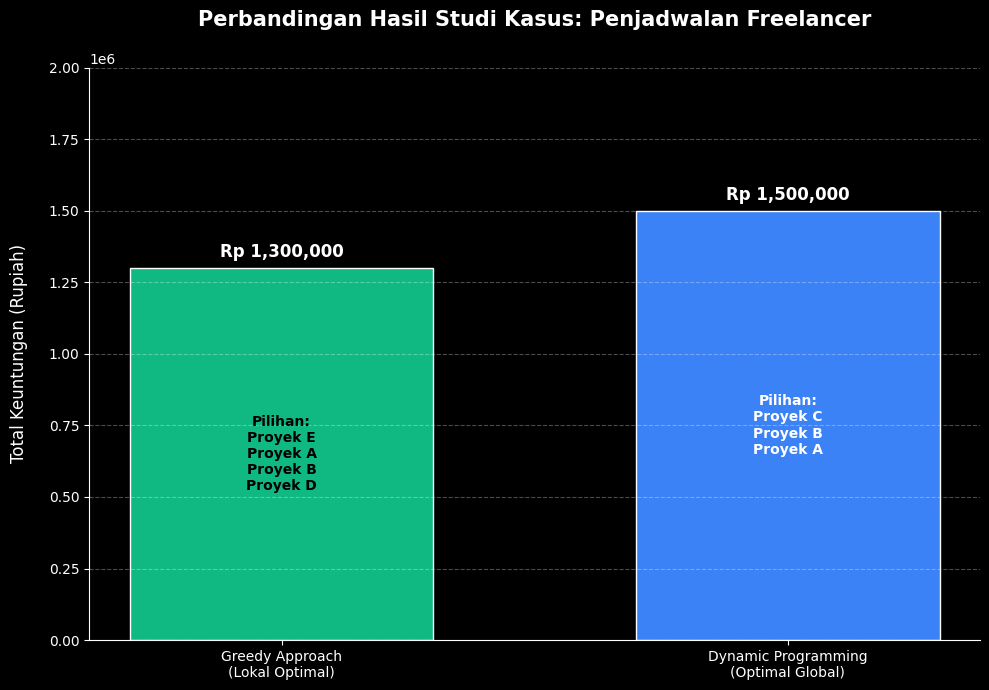

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. SETUP DATA STUDI KASUS (Freelancer IT)
# ==============================================================================
# Kapasitas waktu kerja: 10 Jam
CAPACITY = 10

# Dataset Proyek: {Nama, Durasi (Jam), Keuntungan (Rupiah)}
projects = [
    {'nama': 'Proyek A', 'jam': 2, 'profit': 400000},
    {'nama': 'Proyek B', 'jam': 3, 'profit': 500000},
    {'nama': 'Proyek C', 'jam': 5, 'profit': 600000},
    {'nama': 'Proyek D', 'jam': 4, 'profit': 100000},
    {'nama': 'Proyek E', 'jam': 1, 'profit': 300000}
]

# ==============================================================================
# 2. IMPLEMENTASI METODE GREEDY (Berdasarkan Densitas)
# ==============================================================================
def solve_greedy(data, cap):
    # Hitung densitas (Profit/Jam) dan urutkan menurun
    sorted_data = sorted(data, key=lambda x: x['profit']/x['jam'], reverse=True)
    
    total_profit = 0
    total_time = 0
    chosen_names = []
    
    for p in sorted_data:
        if total_time + p['jam'] <= cap:
            total_time += p['jam']
            total_profit += p['profit']
            chosen_names.append(p['nama'])
            
    return total_profit, chosen_names

# ==============================================================================
# 3. IMPLEMENTASI METODE DYNAMIC PROGRAMMING (Optimal Global)
# ==============================================================================
def solve_dp(data, cap):
    n = len(data)
    # Inisialisasi tabel DP (Matrix)
    dp = [[0 for _ in range(cap + 1)] for _ in range(n + 1)]
    
    # Isi tabel DP
    for i in range(1, n + 1):
        p = data[i-1]
        for w in range(1, cap + 1):
            if p['jam'] <= w:
                dp[i][w] = max(p['profit'] + dp[i-1][w-p['jam']], dp[i-1][w])
            else:
                dp[i][w] = dp[i-1][w]
    
    # Backtracking untuk mencari proyek mana yang dipilih
    res = dp[n][cap]
    w = cap
    chosen_names = []
    for i in range(n, 0, -1):
        if res <= 0:
            break
        if res == dp[i-1][w]:
            continue
        else:
            p = data[i-1]
            chosen_names.append(p['nama'])
            res -= p['profit']
            w -= p['jam']
            
    return dp[n][cap], chosen_names

# ==============================================================================
# 4. EKSEKUSI & PERHITUNGAN
# ==============================================================================
profit_greedy, items_greedy = solve_greedy(projects, CAPACITY)
profit_dp, items_dp = solve_dp(projects, CAPACITY)

print(f"Hasil Greedy: Rp {profit_greedy:,} | Proyek: {', '.join(items_greedy)}")
print(f"Hasil DP    : Rp {profit_dp:,} | Proyek: {', '.join(items_dp)}")

# ==============================================================================
# 5. VISUALISASI DENGAN MATPLOTLIB (TEMA PRESENTASI)
# ==============================================================================
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 7))

# Data Grafik
labels = ['Greedy Approach\n(Lokal Optimal)', 'Dynamic Programming\n(Optimal Global)']
profits = [profit_greedy, profit_dp]
colors = ['#10B981', '#3B82F6'] # Emerald & Navy

# Membuat Bar Chart
bars = ax.bar(labels, profits, color=colors, width=0.6, edgecolor='white', linewidth=1)

# Menambahkan Label Nominal di Atas Bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'Rp {height:,}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), # Jarak teks 5pt di atas bar
                textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='white')

# Menambahkan Keterangan Proyek yang Dipilih di dalam Bar
ax.text(0, profit_greedy/2, f"Pilihan:\n{chr(10).join(items_greedy)}", 
        ha='center', va='center', color='black', fontweight='bold', fontsize=10)
ax.text(1, profit_dp/2, f"Pilihan:\n{chr(10).join(items_dp)}", 
        ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# Kustomisasi Sumbu & Judul
ax.set_ylabel('Total Keuntungan (Rupiah)', fontsize=12, labelpad=15)
ax.set_title('Perbandingan Hasil Studi Kasus: Penjadwalan Freelancer', fontsize=15, fontweight='bold', pad=30)
ax.set_ylim(0, 2000000) # Memberi ruang di atas agar teks tidak terpotong
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

# Menghilangkan border atas dan kanan agar lebih bersih
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Simpan untuk PPT
plt.savefig('studi_kasus_visual.png', dpi=300, transparent=True)
plt.show()

--- Hasil Analisis Studi Kasus ---
Greedy -> Profit: Rp 1,300,000 | Proyek: Proyek E, Proyek A, Proyek B, Proyek D | Waktu: 1.767 µs
DP     -> Profit: Rp 1,500,000 | Proyek: Proyek C, Proyek B, Proyek A | Waktu: 14.003 µs


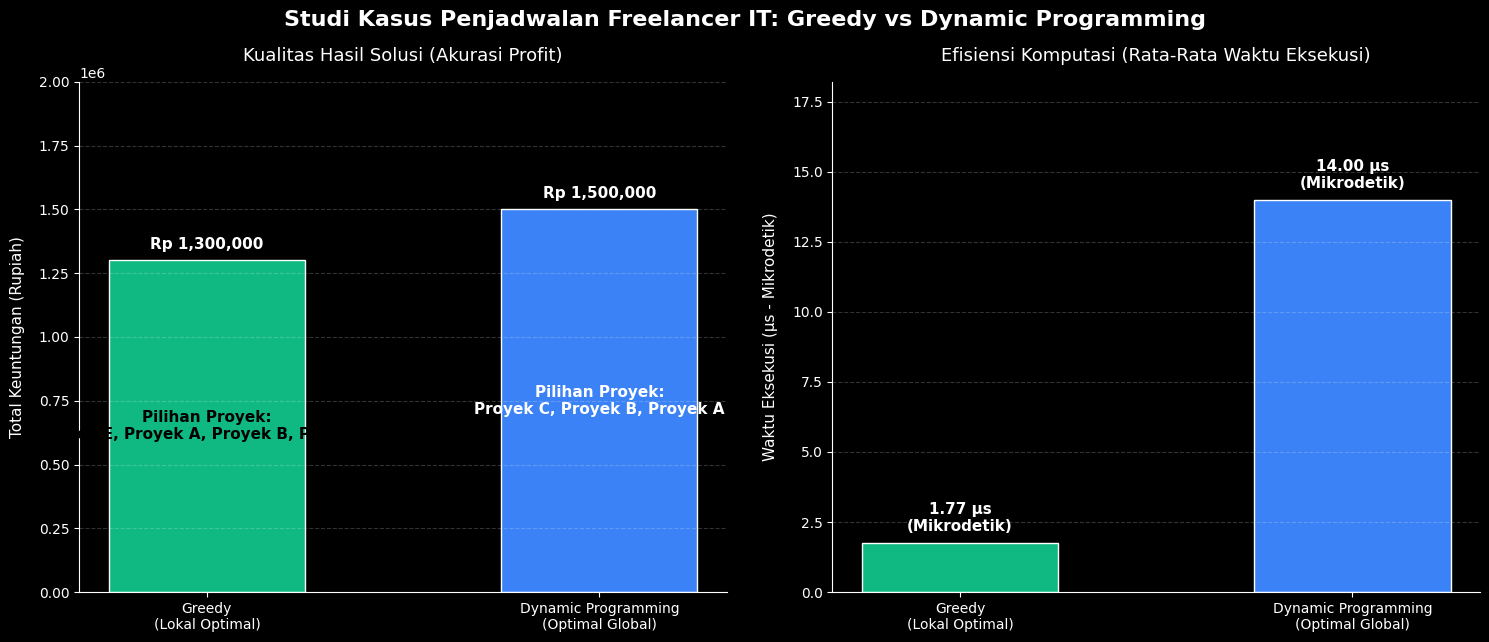

In [ ]:
import time
import matplotlib.pyplot as plt

# ==============================================================================
# 1. SETUP DATA STUDI KASUS (Freelancer IT)
# ==============================================================================
# Kapasitas waktu kerja: 10 Jam
CAPACITY = 10

# Dataset Proyek: {Nama, Durasi (Jam), Keuntungan (Rupiah)}
projects = [
    {'nama': 'Proyek A', 'jam': 2, 'profit': 400000},
    {'nama': 'Proyek B', 'jam': 3, 'profit': 500000},
    {'nama': 'Proyek C', 'jam': 5, 'profit': 600000},
    {'nama': 'Proyek D', 'jam': 4, 'profit': 100000},
    {'nama': 'Proyek E', 'jam': 1, 'profit': 300000}
]

# ==============================================================================
# 2. IMPLEMENTASI METODE GREEDY (Berdasarkan Densitas)
# ==============================================================================
def solve_greedy(data, cap):
    # Hitung densitas (Profit/Jam) dan urutkan menurun
    sorted_data = sorted(data, key=lambda x: x['profit']/x['jam'], reverse=True)
    
    total_profit = 0
    total_time = 0
    chosen_names = []
    
    for p in sorted_data:
        if total_time + p['jam'] <= cap:
            total_time += p['jam']
            total_profit += p['profit']
            chosen_names.append(p['nama'])
            
    return total_profit, chosen_names

# ==============================================================================
# 3. IMPLEMENTASI METODE DYNAMIC PROGRAMMING (Optimal Global)
# ==============================================================================
def solve_dp(data, cap):
    n = len(data)
    # Inisialisasi tabel DP (Matrix)
    dp = [[0 for _ in range(cap + 1)] for _ in range(n + 1)]
    
    # Isi tabel DP
    for i in range(1, n + 1):
        p = data[i-1]
        for w in range(1, cap + 1):
            if p['jam'] <= w:
                dp[i][w] = max(p['profit'] + dp[i-1][w-p['jam']], dp[i-1][w])
            else:
                dp[i][w] = dp[i-1][w]
    
    # Backtracking untuk mencari proyek mana yang dipilih
    res = dp[n][cap]
    w = cap
    chosen_names = []
    for i in range(n, 0, -1):
        if res <= 0:
            break
        if res == dp[i-1][w]:
            continue
        else:
            p = data[i-1]
            chosen_names.append(p['nama'])
            res -= p['profit']
            w -= p['jam']
            
    return dp[n][cap], chosen_names

# ==============================================================================
# 4. BENCHMARK RATA-RATA WAKTU EKSEKUSI (10.000 Iterasi)
# ==============================================================================
# Menjalankan fungsi berulang kali agar mendapatkan nilai rata-rata waktu yang stabil
iterations = 10000

# Pengukuran Greedy
t0 = time.perf_counter()
for _ in range(iterations):
    profit_greedy, items_greedy = solve_greedy(projects, CAPACITY)
t1 = time.perf_counter()
avg_time_greedy = ((t1 - t0) / iterations) * 1_000_000  # Konversi ke mikrodetik (µs)

# Pengukuran DP
t0 = time.perf_counter()
for _ in range(iterations):
    profit_dp, items_dp = solve_dp(projects, CAPACITY)
t1 = time.perf_counter()
avg_time_dp = ((t1 - t0) / iterations) * 1_000_000  # Konversi ke mikrodetik (µs)

print("--- Hasil Analisis Studi Kasus ---")
print(f"Greedy -> Profit: Rp {profit_greedy:,} | Proyek: {', '.join(items_greedy)} | Waktu: {avg_time_greedy:.3f} µs")
print(f"DP     -> Profit: Rp {profit_dp:,} | Proyek: {', '.join(items_dp)} | Waktu: {avg_time_dp:.3f} µs")

# ==============================================================================
# 5. VISUALISASI BERDAMPINGAN DENGAN MATPLOTLIB (TEMA PRESENTASI GELAP)
# ==============================================================================
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))

# Judul Utama Gambar
fig.suptitle('Studi Kasus Penjadwalan Freelancer IT: Greedy vs Dynamic Programming', 
             fontsize=16, fontweight='bold', y=0.98)

# --- PALET WARNA PRESENTASI ---
COLOR_GREEDY = '#10B981'  # Emerald Green
COLOR_DP = '#3B82F6'      # Slate Blue
labels = ['Greedy\n(Lokal Optimal)', 'Dynamic Programming\n(Optimal Global)']
colors = [COLOR_GREEDY, COLOR_DP]

# ------------------------------------------------------------------------------
# GRAFIK 1: PERBANDINGAN PROFIT & PROYEK TERPILIH (KIRI)
# ------------------------------------------------------------------------------
bars1 = ax1.bar(labels, [profit_greedy, profit_dp], color=colors, width=0.5, edgecolor='white', linewidth=1)

# Menampilkan Label Nilai Nominal di Atas Bar
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'Rp {height:,}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 6),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=11, fontweight='bold', color='white')

# Menampilkan Teks Keterangan Proyek Terpilih di Tengah Batang Bar
ax1.text(0, profit_greedy/2, f"Pilihan Proyek:\n{', '.join(items_greedy)}", 
         ha='center', va='center', color='black', fontweight='bold', fontsize=11)
ax1.text(1, profit_dp/2, f"Pilihan Proyek:\n{', '.join(items_dp)}", 
         ha='center', va='center', color='white', fontweight='bold', fontsize=11)

ax1.set_title('Kualitas Hasil Solusi (Akurasi Profit)', fontsize=13, pad=15)
ax1.set_ylabel('Total Keuntungan (Rupiah)', fontsize=11, labelpad=10)
ax1.set_ylim(0, 2_000_000)
ax1.yaxis.grid(True, linestyle='--', alpha=0.2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ------------------------------------------------------------------------------
# GRAFIK 2: PERBANDINGAN RATA-RATA WAKTU EKSEKUSI (KANAN)
# ------------------------------------------------------------------------------
bars2 = ax2.bar(labels, [avg_time_greedy, avg_time_dp], color=colors, width=0.5, edgecolor='white', linewidth=1)

# Menampilkan Label Waktu di Atas Bar
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.2f} µs\n(Mikrodetik)',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 6),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=11, fontweight='bold', color='white')

ax2.set_title('Efisiensi Komputasi (Rata-Rata Waktu Eksekusi)', fontsize=13, pad=15)
ax2.set_ylabel('Waktu Eksekusi (µs - Mikrodetik)', fontsize=11, labelpad=10)
# Memberikan ruang kosong di atas grafik agar teks label tidak menempel di batas atas
ax2.set_ylim(0, max(avg_time_greedy, avg_time_dp) * 1.3)
ax2.yaxis.grid(True, linestyle='--', alpha=0.2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Merapikan tata letak subplots
plt.tight_layout()

# Menyimpan gambar dengan transparansi agar menyatu mulus di PPT
plt.savefig('visualisasi_studi_kasus_lengkap.png', dpi=300, transparent=True)
plt.show()  